# Inspection of nominatim querys
This notebook extracts and plots the polygons of cities from the OSM, using nominatim queries.

## Setup

In [1]:
%run -i "functions.py"
cityfilename = "european_100000pop_dev.csv"
boundarycheck_quick = False

## Load cities

In [84]:
with open('../cities/'+cityfilename, mode='r') as infile:
    reader = csv.reader(infile, delimiter=";")
    header = next(reader)
    cities = {slugify(rows[0]) + '_' + slugify(rows[4]): {header[0]: rows[0], header[1]: rows[1], header[2]: rows[2], header[3]: rows[3], header[4]: rows[4], header[5]: rows[5]} for rows in reader}
os.makedirs("../plots/", exist_ok=True)

## Check city boundaries

In [85]:
CACHE_DIR = "../cache/nominatim"
os.makedirs(CACHE_DIR, exist_ok=True)

def geocode_cached(cityid,query, check_cache = True):
    cache_file = os.path.join(CACHE_DIR, f"{cityid}.geojson")

    if check_cache and os.path.exists(cache_file):
        gdf = gpd.read_file(cache_file)
    else:
        try:
            gdf = ox.geocoder.geocode_to_gdf(query)
        except TypeError:
            return "no_polygon"
        except ox._errors.InsufficientResponseError:
            return "no_results"
        gdf.to_file(cache_file, driver="GeoJSON")
        time.sleep(1)
        
    return shapely.geometry.shape(gdf['geometry'][0])

In [86]:
cities_with_no_polygon = []
cities_with_multipolygon = []
cities_with_no_results = []

for i, (cityid, city_info) in enumerate(tqdm(cities.items(), desc="Checking city boundaries", position=0, leave=True)):
    country = slugify(city_info['country_en'])
    
    city_name = cityid.split("_")[0]
    output_path = f"../plots/{country}/boundary_{city_name}.jpeg"
    if os.path.exists(output_path):
        continue

    # Draw location polygons and their holes
    if city_info["nominatim_query"]:
        location = geocode_cached(cityid, city_info["nominatim_query"])
        if location == "no_polygon":
            cities_with_no_polygon.append(city_info["name_en"])
            continue
        if location == "no_results":
            cities_with_no_results.append(city_info["name_en"])
            continue
        is_poly, geoms, has_holes, polyg = analyse_polygon(location)
    else:
        # https://github.com/mszell/bikenwgrowth/blob/main/code/01_prepare_networks.ipynb
        shp = gpd.read_file("../cities/"+cityid+".shp")
        location = shp.iloc[0].geometry

    if not is_poly:
        cities_with_no_polygon.append(city_info["name_en"])
        continue

    if geoms > 1:
        cities_with_multipolygon.append(city_info["name_en"])

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)
    
    contextily.add_basemap(ax=ax, url=contextily.providers.CartoDB.Positron, crs='EPSG:4326', alpha = 0.5)
    plt.gca().set_aspect('equal')
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    #plt.show()
    fig.savefig(f"../plots/{country}/boundary_{city_name}.jpeg", dpi=150, bbox_inches='tight')
    plt.close()

Checking city boundaries: 100%|██████████| 456/456 [00:01<00:00, 257.55it/s]


## Individual checks

First we check the cities which queries didn't return any result, and change the nominatim queries to something fitting.

Then we check the cities which queries didn't return a polygon, and change the nominatim queries to something fitting.

Finally, we checked each city individually comparing the plot polygon with the equivalent in Google Maps, labelling according the following tags:
- **good**: if the polygon is the same
- **bigger**: if the polygon was bigger, extracting metropolitan areas or whole regions instead of just the municipality
- **different**: if the polygon extracted was from a different location

### Non-capital European cities

#### Cities with no results

In [16]:
# First pass
# Check which cities had no results from the query
cities_with_no_results

['Pésterion', 'Shauliai']

These cities had the wrong name in the UN Demographics Yearbook

- Pésterion = Peristeri (Greece)
- Shauliai = Šiauliai (Lithuania)

In [ ]:
# Make the changes
cities["peristeri_gr"] = cities.pop("pesterion")
cities["peristeri_gr"]["name_en"] = "Peristeri"
cities["peristeri_gr"]["nominatim_query"] = "Peristeri"

cities["siauliai_lt"] = cities.pop("shauliai")
cities["siauliai_lt"]["name_en"] = "Šiauliai"
cities["siauliai_lt"]["nominatim_query"] = "Šiauliai"

In [19]:
# Second pass
# Check which cities had no results from the query
cities_with_no_results

[]

#### Cities without a polygon

In [20]:
# First pass
# Check cities where the query returned a geometry but it was not a polygon
cities_with_no_polygon

['Calithèa', 'Heraklion', 'Larissa', 'Patras']

These cities had a geometry extracted that wasn't a polygon:

Denmark:
- Aalborg
- Aarhus
- Esbjerg
- Frederiksberg
- Odense
- Vejle

Greece:
- Piraeus
- Heraklion
- Larissa
- Calithèa
- Patras

Ukraine:
- Luts'K
- Uzhhorod

They represent all Danish and Greek cities, and some from Ukraine.

In [ ]:
# For Danish cities, we add "Municipality" in the query
cities['aalborg_dk']['nominatim_query'] = "Aalborg Municipality"
cities['aarhus_dk']['nominatim_query'] = "Aarhus Municipality"
cities['esbjerg_dk']['nominatim_query'] = "Esbjerg Municipality"
cities['frederiksberg_dk']['nominatim_query'] = "Frederiksberg Municipality"
cities['odense_dk']['nominatim_query'] = "Odense Municipality"
cities['vejle_dk']['nominatim_query'] = "Vejle Municipality"


# For Greek cities, we use the Greek name in the query 
cities['piraeus_gr']['nominatim_query'] = "Πειραιάς"
cities['heraklion_gr']['nominatim_query'] = "Ηράκλειο"
cities['larissa_gr']['nominatim_query'] = "Λάρισα"

cities["kallithea_gr"] = cities.pop("calithea") # The city Kallithea was mispelled from the UN source.
cities["kallithea_gr"]["name_en"] = "Kallithea"
cities["kallithea_gr"]["nominatim_query"] = "Καλλιθέα"

cities['patras_gr']['nominatim_query'] = "Πάτρα"


# For Ukraine we correct the name and use a tested nominatim in OSM's nominatim web interface
cities['luts-k_ua']['nominatim_query'] = "Lutsk" # The city Lutsk was mispelled from the UN source.
cities['uzhhorod_ua']['nominatim_query'] = "Uzhhorod Urban Hromada"

In [ ]:
# Second pass (after re-running the loop cell in "Check city boundaries")
# Check cities where the query returned a geometry but it was not a polygon
cities_with_no_polygon

['Heraklion', 'Larissa', 'Patras']

For each of the 3 cities, we find a working nominatim:

New query returns a multipolygon.


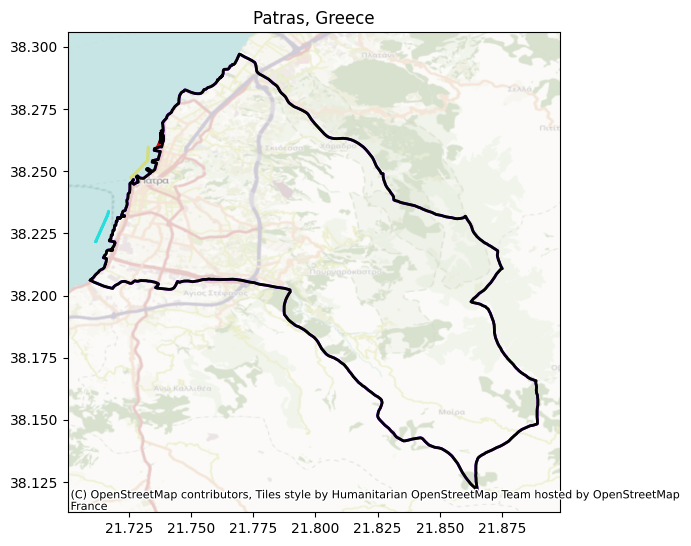

In [ ]:
# (This cell is run for all three cities, changing the variable 'city' and 'new_nominatim_query')

# Draw location polygons and their holes
city = 'patras_gr'
city_info = cities[city]
new_nominatim_query = "Municipal Unit of Patras"



location = geocode_cached(city, new_nominatim_query, check_cache=False)
if location == "no_polygon":
    print("New query doesn't return a polygon.")
    
elif location == "no_results":
    print("New query doesn't return any result.")
        
else:
    is_poly, geoms, has_holes, polyg = analyse_polygon(location)


    if not is_poly:
        print("New query doesn't return a polygon.")
        

    if geoms > 1:
        print("New query returns a multipolygon.")
        

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)

    contextily.add_basemap(ax=ax, url=contextily.providers.CartoDB.Positron, crs='EPSG:4326', alpha = 0.5)
    plt.gca().set_aspect('equal')
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    plt.show()

In [ ]:
city_name = city.split('_')[0]
fig.savefig(f"../plots/boundary_{city_name}.jpeg", dpi=150, bbox_inches='tight')
plt.close()
cities[city]['nominatim_query'] = new_nominatim_query

#### Update CSV before individual checks

In [44]:
cityfilepath = '../cities/european_100000pop_dev.csv'

with open(cityfilepath, mode='w', newline = '', encoding='utf-8') as outfile:
    writer = csv.DictWriter(
        outfile,
        fieldnames = header,
        delimiter = ";"
    )

    writer.writeheader()
    writer.writerows(cities.values())

#### Cities tagged as different (in local folder)

In [ ]:
cities_different = []
for i, (cityid, city_info) in enumerate(tqdm(cities.items(), desc="Extracting cities with different polygon", position=0, leave=True)):
    city_name = cityid.split('_')[0]
    country = slugify(city_info['country_en'])
    figpath = f"../plots/{country}/boundary_{city_name}.jpeg"
    tags = get_tags(figpath)
    if 'different' in tags:
        cities_different.append(city_info["name_en"])

with open("../external_data/cities_with_different_polygon.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f, delimiter = ";")
    writer.writerow(cities_different)

Extracting cities with different polygon: 100%|██████████| 455/455 [00:28<00:00, 15.92it/s]


In [52]:
cities_different

['Belfast',
 'Bradford',
 'Cardiff',
 'Coventry',
 'Ede',
 'Glasgow',
 'Gothenburg',
 'Granada',
 'Leicester',
 'León',
 'Lida',
 'Montreuil',
 'Nis',
 'Nîmes',
 'Porto',
 'Siegen',
 'Westland']

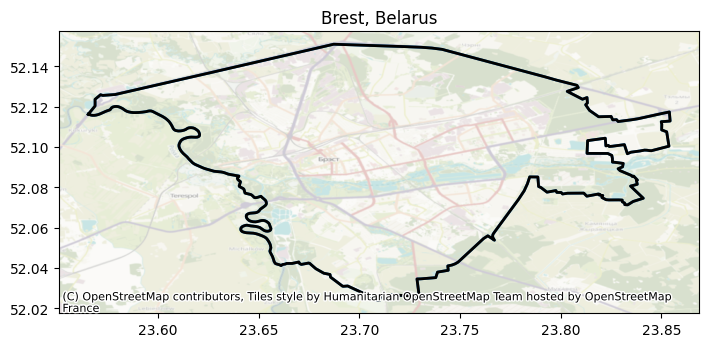

In [90]:
# (This cell is run for all cities, changing the variable 'city' and 'new_nominatim_query')

# Draw location polygons and their holes
city = 'brest_by'
city_info = cities[city]
country = slugify(city_info['country_en'])
new_nominatim_query = "Brest, Belarus"



location = geocode_cached(city, new_nominatim_query, check_cache=False)
if location == "no_polygon":
    print("New query doesn't return a polygon.")
    
elif location == "no_results":
    print("New query doesn't return any result.")
        
else:
    is_poly, geoms, has_holes, polyg = analyse_polygon(location)


    if not is_poly:
        print("New query doesn't return a polygon.")
        

    if geoms > 1:
        print("New query returns a multipolygon.")
        

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)

    contextily.add_basemap(ax=ax, url=contextily.providers.CartoDB.Positron, crs='EPSG:4326', alpha = 0.5)
    plt.gca().set_aspect('equal')
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    plt.show()

In [92]:
city_name = city.split('_')[0]
fig.savefig(f"../plots/{country}/boundary_{city_name}.jpeg", dpi=150, bbox_inches='tight')
plt.close()
cities[city]['nominatim_query'] = new_nominatim_query

#### Update CSV before other checks

In [93]:
cityfilepath = '../cities/european_100000pop_dev.csv'

with open(cityfilepath, mode='w', newline = '', encoding='utf-8') as outfile:
    writer = csv.DictWriter(
        outfile,
        fieldnames = header,
        delimiter = ";"
    )

    writer.writeheader()
    writer.writerows(cities.values())

#### Cities tagged as bigger (in local folder)

In [ ]:
cities_with_bigger_polygon = []
cities_with_bigger_polygon_id = []


for i, (cityid, city_info) in enumerate(tqdm(cities.items(), desc="Extracting cities with a bigger polygon", position=0, leave=True)):
    city_name = cityid.split('_')[0]
    figpath = f"../plots/boundary_{city_name}.jpeg"
    polypath = CACHE_DIR + f"/{cityid}.geojson"
    tags = get_tags(figpath)
    if 'bigger' in tags:
        cities_with_bigger_polygon.append(city_info["name_en"])
        cities_with_bigger_polygon_id.append(cityid)



with open("../external_data/cities_with_bigger_polygon.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f, delimiter = ";")
    writer.writerow(cities_with_bigger_polygon)

Extracting cities with a bigger polygon: 100%|██████████| 455/455 [00:15<00:00, 29.72it/s]


In [116]:
cities_with_bigger_polygon

['A Coruña',
 'Aalborg',
 'Aarhus',
 'Aberdeen',
 'Albacete',
 'Algeciras',
 'Alicante/Alacant',
 'Badajoz',
 'Barakaldo',
 'Bilbao',
 'Bologna',
 'Bolton',
 'Bolzano',
 'Bradford',
 'Braga',
 'Brescia',
 'Brighton And Hove',
 'Burgas',
 'Burgos',
 'Cagliari',
 'Cardiff',
 'Cartagena',
 'Catania',
 'Cherkasy',
 'Chernihiv',
 'Coimbra',
 'Cordova',
 'Cádiz',
 'Donetsk',
 'Donostia/San Sebastián',
 'Dos Hermanas',
 'Durrës',
 'Ede',
 'Edinburgh',
 'Elche/Elx',
 'Emmen',
 'Esbjerg',
 'Espoo',
 'Ferrara',
 'Foggia',
 'Forli',
 'Fuenlabrada',
 'Geneva',
 'Genoa',
 'Getafe',
 'Gijón',
 'Girona',
 'Giugliano In Campania',
 'Granada',
 'Helsingborg',
 'Huelva',
 'Ivano-Frankivsk',
 'Jaén',
 'Jerez De La Frontera',
 'Jönköping',
 'Kherson',
 'Khmelnitsky',
 'Larissa',
 'Las Palmas De Gran Canaria',
 'Latina',
 'Leeds',
 'Leganés',
 'León',
 'Linköping',
 'Livorno',
 'Lleida',
 'Logroño',
 'Lublin',
 'Luhansk',
 'Mataró',
 'Messina',
 'Modena',
 'Monza',
 'Murcia',
 'Málaga',
 'Móstoles',
 'Norr

In [118]:
bigger_cities = pd.DataFrame.from_dict(
    cities,
    orient = 'index'
).loc[cities_with_bigger_polygon_id]
bigger_cities

,name_en,country_en,nominatim_query,name,alpha-2,population
a-coruna,A Coruña,Spain,A Coruña,A Coruña,ES,245541
aalborg,Aalborg,Denmark,Aalborg Municipality,Ålborg,DK,219476
aarhus,Aarhus,Denmark,Aarhus Municipality,Århus,DK,352315
aberdeen,Aberdeen,United Kingdom,Aberdeen,Aberdeen,GB,207932
albacete,Albacete,Spain,Albacete,Albacete,ES,172806
...,...,...,...,...,...,...
vitebsk,Vitebsk,Belarus,Vitebsk,Vitebsk,BY,364862
vitoria-gasteiz,Vitoria-Gasteiz,Spain,Vitoria-Gasteiz,Vitoria-Gasteiz,ES,252953
vasteras,Västerås,Sweden,Västerås,Västerås,SE,133324
zaragoza,Zaragoza,Spain,Zaragoza,Zaragoza,ES,681430


In [125]:
bigger_cities.groupby(by='country_en')['name'].count()

country_en
Albania            1
Belarus            2
Bulgaria           3
Denmark            4
Finland            1
Greece             3
Italy             36
Netherlands        2
Poland             2
Portugal           3
Serbia             1
Spain             47
Sweden             7
Switzerland        1
Ukraine           13
United Kingdom    11
Name: name, dtype: int64

The countries where the returned polygon is bigger than the city displayed on Google Maps are:
- Albania: 1 ✅
- Belarus: 2 ✅
- Bulgaria: 3 ✅
- Denmark: 4 ✅
- Finland: 1 ✅
- Greece: 3 ✅
- Italy: 36 ✅
- Netherlands: 2 ✅
- Poland: 2 ✅
- Portugal: 3 ✅
- Serbia: 1 ✅
- Spain: 47 ✅
- Sweden: 7 ✅
- Switzerland: 1 ✅
- Ukraine: 13 ✅
- United Kingdom: 11 ✅

Numbers indicate the number of cities per country.

In [252]:
bigger_cities.query("country_en == 'Spain'")

,name_en,country_en,nominatim_query,name,alpha-2,population
a-coruna,A Coruña,Spain,A Coruña,A Coruña,ES,245541
albacete,Albacete,Spain,Albacete,Albacete,ES,172806
algeciras,Algeciras,Spain,Algeciras,Algeciras,ES,123435
alicante-alacant,Alicante/Alacant,Spain,Alicante/Alacant,Alicante/Alacant,ES,338768
badajoz,Badajoz,Spain,Badajoz,Badajoz,ES,151048
barakaldo,Barakaldo,Spain,Barakaldo,Barakaldo,ES,100847
bilbao,Bilbao,Spain,Bilbao,Bilbao,ES,345749
burgos,Burgos,Spain,Burgos,Burgos,ES,174154
cartagena,Cartagena,Spain,Cartagena,Cartagena,ES,215826
cordova,Cordova,Spain,Cordova,Córdoba,ES,322327


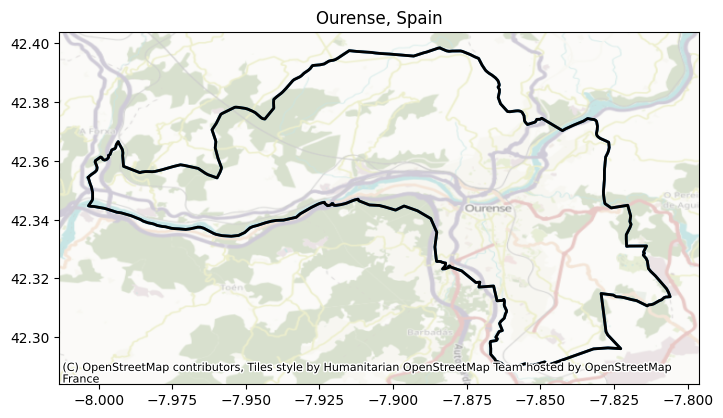

In [265]:
# Draw location polygons and their holes
city = 'ourense'
city_info = cities[city]
new_nominatim_query = "Ourense, Ourense"



location = geocode_cached(city, new_nominatim_query, check_cache=False)
if location == "no_polygon":
    print("New query doesn't return a polygon.")
    
elif location == "no_results":
    print("New query doesn't return any result.")
        
else:
    is_poly, geoms, has_holes, polyg = analyse_polygon(location)


    if not is_poly:
        print("New query doesn't return a polygon.")
        

    if geoms > 1:
        print("New query returns a multipolygon.")
        

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)

    contextily.add_basemap(ax=ax, url=contextily.providers.CartoDB.Positron, crs='EPSG:4326', alpha = 0.5)
    plt.gca().set_aspect('equal')
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    plt.show()


In [266]:
fig.savefig(f"../plots/boundary_{city}.jpeg", dpi=150, bbox_inches='tight')
plt.close()
cities[city]['nominatim_query'] = new_nominatim_query

For Ucranian cities, the polygons identified were from the bigger admnistrative units (Oblast), instead of the cities themselves.

To correct this, we changed all nominatims to have the name of the city twice: "{city}, {city}", so that first corresponds to the city and the second to the Oblast.

#### Update CSV before other checks

In [268]:
cityfilepath = '../cities/european_100000pop_dev.csv'

with open(cityfilepath, mode='w', newline = '', encoding='utf-8') as outfile:
    writer = csv.DictWriter(
        outfile,
        fieldnames = header,
        delimiter = ";"
    )

    writer.writeheader()
    writer.writerows(cities.values())

## Merge comments on Excel file with new csv

In [2]:
cities_df = pd.read_csv(
    "../cities/european_100000pop_dev.csv",
    sep = ";",
    header = 0,
)
cities_df

,name_en,country_en,nominatim_query,name,alpha-2,population
0,A Coruña,Spain,A Coruña,A Coruña,ES,245541
1,Aachen,Germany,Aachen,Aachen,DE,247380
2,Aalborg,Denmark,Aalborg Municipality,Ålborg,DK,219476
3,Aarhus,Denmark,Aarhus Municipality,Århus,DK,352315
4,Aberdeen,United Kingdom,Aberdeen,Aberdeen,GB,207932
...,...,...,...,...,...,...
451,Zielona Góra,Poland,Zielona Góra,Zielona Góra,PL,141631
452,Zoetermeer,Netherlands,Zoetermeer,Zoetermeer,NL,124025
453,Zurich,Switzerland,Zurich,Zürich,CH,423193
454,Zwolle,Netherlands,Zwolle,Zwolle,NL,123861


In [25]:
comments_df = pd.read_excel(
    "../cities/european_100000pop_comments.xlsx",
    sheet_name = 'Comments',
    header = 0,
)
comments_df

,name_en,country_en,nominatim_query,name,alpha-2,population,comments,accepted
0,A Coruña,Spain,A Coruña,A Coruña,ES,245541,"Polygon is OSM bigger than Maps, but there is ...",0
1,Aachen,Germany,Aachen,Aachen,DE,247380,NaN,1
2,Aalborg,Denmark,Aalborg,Ålborg,DK,219476,"Polygon is OSM bigger than Maps, but there is ...",0
3,Aarhus,Denmark,Aarhus,Århus,DK,352315,"Polygon is OSM bigger than Maps, but there is ...",0
4,Aberdeen,United Kingdom,Aberdeen,Aberdeen,GB,207932,"Polygon is OSM bigger than Maps, but there is ...",0
...,...,...,...,...,...,...,...,...
451,Zhytomyr,Ukraine,Zhytomyr,Zhytomyr,UA,260367,Insignificant differences,1
452,Zielona Góra,Poland,Zielona Góra,Zielona Góra,PL,141631,NaN,1
453,Zoetermeer,Netherlands,Zoetermeer,Zoetermeer,NL,124025,NaN,1
454,Zurich,Switzerland,Zurich,Zürich,CH,423193,NaN,1


In [26]:
print("Cities in the Excel, but not in csv:")
print(set(comments_df['name_en']) - set(cities_df['name_en']))

Cities in the Excel, but not in csv:
set()


In [27]:
cities_with_comments = cities_df.merge(
    comments_df[['name_en', 'alpha-2', 'comments', 'accepted']],
    on = ['name_en', 'alpha-2'],
    how = 'left'
)
cities_with_comments

,name_en,country_en,nominatim_query,name,alpha-2,population,comments,accepted
0,A Coruña,Spain,A Coruña,A Coruña,ES,245541,"Polygon is OSM bigger than Maps, but there is ...",0
1,Aachen,Germany,Aachen,Aachen,DE,247380,NaN,1
2,Aalborg,Denmark,Aalborg Municipality,Ålborg,DK,219476,"Polygon is OSM bigger than Maps, but there is ...",0
3,Aarhus,Denmark,Aarhus Municipality,Århus,DK,352315,"Polygon is OSM bigger than Maps, but there is ...",0
4,Aberdeen,United Kingdom,Aberdeen,Aberdeen,GB,207932,"Polygon is OSM bigger than Maps, but there is ...",0
...,...,...,...,...,...,...,...,...
451,Zielona Góra,Poland,Zielona Góra,Zielona Góra,PL,141631,NaN,1
452,Zoetermeer,Netherlands,Zoetermeer,Zoetermeer,NL,124025,NaN,1
453,Zurich,Switzerland,Zurich,Zürich,CH,423193,NaN,1
454,Zwolle,Netherlands,Zwolle,Zwolle,NL,123861,NaN,1


In [30]:
# Save clean european_100000pop.csv
european_100000pop = cities_with_comments.query("accepted == 1")[['name_en', 'country_en', 'nominatim_query', 'alpha-2', 'population']]
european_100000pop.to_csv(
    "../cities/european_100000pop.csv",
    sep = ";",
    index = False,
)